# Machine Learning Modeling for Depression Risk Prediction

Following the exploratory data analysis (EDA) phase, the next step in the analytical pipeline is to build predictive models capable of identifying individuals at higher risk of depression.

The goal of this modeling stage is to evaluate how well different machine learning algorithms can distinguish between individuals who have experienced depression and those who have not, based on demographic, lifestyle, and health-related variables derived from the BRFSS 2021 dataset.

Several models are tested to compare performance and interpretability:

• Logistic Regression – a baseline interpretable statistical model  
• Random Forest – an ensemble tree-based method capable of capturing nonlinear relationships  
• K-Nearest Neighbors – a distance-based classification approach  
• XGBoost – a powerful gradient boosting algorithm often used for structured tabular data

Each model is evaluated using multiple performance metrics including:

• **AUC (Area Under the ROC Curve)** – measures how well the model distinguishes between depressed and non-depressed individuals  
• **Accuracy** – percentage of correct predictions  
• **Recall** – ability of the model to correctly identify individuals experiencing depression  
• **Precision** – proportion of predicted positive cases that are correct

These metrics allow us to assess not only overall performance but also the model’s ability to capture high-risk individuals, which is especially important in public health contexts.

In [1]:
# ============================================================
# MODELING NOTEBOOK — Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Paths
BASE_DIR    = Path.cwd().parent
PROCESSED   = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
TABLES_DIR  = BASE_DIR / "outputs" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Load train/test splits saved from Week 1
X_train = pd.read_csv(PROCESSED / "X_train.csv")
X_test  = pd.read_csv(PROCESSED / "X_test.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

print(f" X_train : {X_train.shape}")
print(f" X_test  : {X_test.shape}")
print(f" y_train : {y_train.shape}")
print(f" y_test  : {y_test.shape}")
print(f"\nClass balance in y_train:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

 X_train : (210172, 96)
 X_test  : (52544, 96)
 y_train : (210172,)
 y_test  : (52544,)

Class balance in y_train:
Ever_Depressive_Disorder
0    79.8
1    20.2
Name: proportion, dtype: float64


Installing libraries

In [2]:
# ============================================================
# Install required libraries
# ============================================================
import subprocess
subprocess.run([
    "pip", "install", "boruta", "xgboost", "scikit-learn"
], capture_output=True)

print(" Libraries installed")

 Libraries installed


In [3]:
# ============================================================
# Import all modeling libraries
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             classification_report, roc_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score
from xgboost import XGBClassifier
from boruta import BorutaPy

print("All modeling libraries imported")

All modeling libraries imported


## Data Preparation

Before training machine learning models, the dataset must be prepared in a format suitable for modeling.

This includes:

• separating predictor variables (features) from the target variable  
• encoding categorical variables where necessary  
• ensuring that all variables are numeric and compatible with machine learning algorithms

The target variable for this project is **Ever_Depressive_Disorder**, which indicates whether an individual has ever been diagnosed with a depressive disorder.

All remaining variables represent potential predictors of depression risk.

## Train-Test Split

To properly evaluate model performance, the dataset is divided into two subsets:

• **Training set** – used to train the machine learning models  
• **Testing set** – used to evaluate how well the model performs on unseen data

This prevents models from memorizing patterns in the dataset and ensures that performance metrics reflect real predictive capability rather than overfitting.

Feature selection

1. BorutaPy

In [4]:
# ============================================================
# MILESTONE 1A — Feature Selection using BorutaPy
#
# BorutaPy works by creating "shadow" copies of all features,
# shuffling them randomly, then checking if real features
# perform better than their random shadow copies.
# Features that consistently beat their shadows are confirmed.
# ============================================================

# BorutaPy requires integer target
y_train_int = y_train.astype(int).values
X_train_arr = X_train.values

# Base estimator — using Random Forest inside Boruta
rf_boruta = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          # keep shallow to speed up
    n_jobs=-1,            # use all CPU cores
    random_state=42
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators="auto",
    max_iter=50,          # max 50 iterations to keep runtime reasonable
    random_state=42,
    verbose=1
)

print("Running BorutaPy feature selection... this may take 10-15 mins ⏳")
boruta.fit(X_train_arr, y_train_int)

# Get confirmed features
boruta_confirmed = list(X_train.columns[boruta.support_])
boruta_tentative = list(X_train.columns[boruta.support_weak_])

print(f"\n✅ BorutaPy complete")
print(f"   Confirmed features : {len(boruta_confirmed)}")
print(f"   Tentative features : {len(boruta_tentative)}")
print(f"   Rejected features  : {96 - len(boruta_confirmed) - len(boruta_tentative)}")
print(f"\nConfirmed features:")
for f in boruta_confirmed:
    print(f"  → {f}")

Running BorutaPy feature selection... this may take 10-15 mins ⏳
Iteration: 1 / 50
Iteration: 2 / 50
Iteration: 3 / 50
Iteration: 4 / 50
Iteration: 5 / 50
Iteration: 6 / 50
Iteration: 7 / 50
Iteration: 8 / 50
Iteration: 9 / 50
Iteration: 10 / 50
Iteration: 11 / 50
Iteration: 12 / 50
Iteration: 13 / 50
Iteration: 14 / 50
Iteration: 15 / 50
Iteration: 16 / 50
Iteration: 17 / 50
Iteration: 18 / 50
Iteration: 19 / 50


BorutaPy finished running.

Iteration: 	20 / 50
Confirmed: 	41
Tentative: 	0
Rejected: 	55

✅ BorutaPy complete
   Confirmed features : 41
   Tentative features : 0
   Rejected features  : 55

Confirmed features:
  → Age_Group
  → Sex
  → Education_Level
  → Income_Level
  → Exercise_Past30Days
  → Smoked_100_Cigarettes
  → Fruit_Per_Day
  → Vegetables_Per_Day
  → BMI_Category
  → General_Health
  → Poor_Physical_Health_Days
  → Poor_Mental_Health_Days
  → Have_Health_Plan
  → Could_Not_Afford_Doctor
  → Ever_Heart_Disease
  → Ever_Stroke
  → Ever_COPD
  → Ever_Arthritis
  →

2. Recursive Feature Elimination (RFE)

In [5]:
# ============================================================
# MILESTONE 1B — Feature Selection using RFE
#
# RFE works differently from Boruta — it trains a model,
# ranks features by importance, drops the weakest one,
# retrains, and repeats until it reaches the target number.
# ============================================================

# Use Logistic Regression as the base estimator for RFE
# Scale first — LR requires scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_rfe = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Select top 40 features (similar to Boruta's 41)
rfe = RFE(
    estimator=lr_rfe,
    n_features_to_select=40,
    step=5,               # drop 5 features per iteration to speed up
    verbose=1
)

print("Running RFE feature selection... ⏳")
rfe.fit(X_train_scaled, y_train)

rfe_confirmed = list(X_train.columns[rfe.support_])

print(f"\n✅ RFE complete")
print(f"   Selected features : {len(rfe_confirmed)}")
print(f"\nRFE selected features:")
for f in rfe_confirmed:
    print(f"  → {f}")

Running RFE feature selection... ⏳
Fitting estimator with 96 features.
Fitting estimator with 91 features.
Fitting estimator with 86 features.
Fitting estimator with 81 features.
Fitting estimator with 76 features.
Fitting estimator with 71 features.
Fitting estimator with 66 features.
Fitting estimator with 61 features.
Fitting estimator with 56 features.
Fitting estimator with 51 features.
Fitting estimator with 46 features.
Fitting estimator with 41 features.

✅ RFE complete
   Selected features : 40

RFE selected features:
  → Age_Group
  → Sex
  → Education_Level
  → Income_Level
  → Smoked_100_Cigarettes
  → BMI_Category
  → General_Health
  → Poor_Mental_Health_Days
  → Have_Health_Plan
  → Could_Not_Afford_Doctor
  → Ever_COPD
  → Ever_Arthritis
  → Ever_Kidney_Disease
  → Marital_Status_1.0
  → Marital_Status_2.0
  → Marital_Status_3.0
  → Marital_Status_4.0
  → Employment_Status_1.0
  → Employment_Status_2.0
  → Employment_Status_8.0
  → Race_Ethnicity_1.0
  → Race_Ethnicity_

Combining BorutaPy & RFE

In [6]:
# ============================================================
# MILESTONE 1C — Combine Boruta + RFE results
#
# Features confirmed by BOTH methods = most reliable
# Features confirmed by EITHER method = worth keeping
# We'll use the INTERSECTION (confirmed by both) as primary
# but also check the union
# ============================================================

boruta_set = set(boruta_confirmed)
rfe_set    = set(rfe_confirmed)

# Features confirmed by both
intersection = sorted(boruta_set & rfe_set)

# Features confirmed by either
union = sorted(boruta_set | rfe_set)

print(f"Boruta confirmed  : {len(boruta_set)} features")
print(f"RFE confirmed     : {len(rfe_set)} features")
print(f"\nConfirmed by BOTH : {len(intersection)} features")
print(f"Confirmed by EITHER: {len(union)} features")

print(f"\n{'='*50}")
print(f"FEATURES CONFIRMED BY BOTH (final selection):")
print(f"{'='*50}")
for f in intersection:
    print(f"  → {f}")

print(f"\n{'='*50}")
print(f"IN BORUTA BUT NOT RFE:")
print(f"{'='*50}")
for f in sorted(boruta_set - rfe_set):
    print(f"  → {f}")

print(f"\n{'='*50}")
print(f"IN RFE BUT NOT BORUTA:")
print(f"{'='*50}")
for f in sorted(rfe_set - boruta_set):
    print(f"  → {f}")

Boruta confirmed  : 41 features
RFE confirmed     : 40 features

Confirmed by BOTH : 25 features
Confirmed by EITHER: 56 features

FEATURES CONFIRMED BY BOTH (final selection):
  → Age_Group
  → BMI_Category
  → Could_Not_Afford_Doctor
  → Diabetes_Status_3.0
  → Education_Level
  → Employment_Status_1.0
  → Employment_Status_2.0
  → Employment_Status_8.0
  → Ever_Arthritis
  → Ever_COPD
  → Ever_Kidney_Disease
  → General_Health
  → Have_Health_Plan
  → Income_Level
  → Marital_Status_1.0
  → Marital_Status_2.0
  → Marital_Status_3.0
  → Marital_Status_4.0
  → Poor_Mental_Health_Days
  → Race_Ethnicity_1.0
  → Race_Ethnicity_2.0
  → Race_Ethnicity_3.0
  → Sex
  → Smoked_100_Cigarettes
  → State_15.0

IN BORUTA BUT NOT RFE:
  → Diabetes_Status_1.0
  → Diabetes_Status_2.0
  → Employment_Status_3.0
  → Employment_Status_4.0
  → Employment_Status_5.0
  → Employment_Status_6.0
  → Employment_Status_7.0
  → Ever_Heart_Disease
  → Ever_Stroke
  → Exercise_Past30Days
  → Fruit_Per_Day
  → Mar

In [7]:
# ============================================================
# MILESTONE 1D — Final Feature Set Decision
#
# Strategy:
# - Use all 41 Boruta confirmed features as base
# - Boruta is more reliable than RFE for tree-based models
# - RFE's extra State features are noise — drop them
# - This gives us a clean, well-justified feature set
# ============================================================

FINAL_FEATURES = boruta_confirmed  # 41 features from Boruta

# Apply to train and test sets
X_train_final = X_train[FINAL_FEATURES].copy()
X_test_final  = X_test[FINAL_FEATURES].copy()

# Scale versions for Logistic Regression and KNN
scaler_final      = StandardScaler()
X_train_scaled    = scaler_final.fit_transform(X_train_final)
X_test_scaled     = scaler_final.transform(X_test_final)

print(f"✅ Final feature set : {len(FINAL_FEATURES)} features")
print(f"✅ X_train_final     : {X_train_final.shape}")
print(f"✅ X_test_final      : {X_test_final.shape}")
print(f"\nFeature selection summary:")
print(f"  Started with      : 96 features")
print(f"  Boruta confirmed  : 41 features")
print(f"  RFE confirmed     : 40 features")
print(f"  Final selected    : {len(FINAL_FEATURES)} features (Boruta)")
print(f"  Dropped           : {96 - len(FINAL_FEATURES)} features")

✅ Final feature set : 41 features
✅ X_train_final     : (210172, 41)
✅ X_test_final      : (52544, 41)

Feature selection summary:
  Started with      : 96 features
  Boruta confirmed  : 41 features
  RFE confirmed     : 40 features
  Final selected    : 41 features (Boruta)
  Dropped           : 55 features


#### Training models: Logistic Regression, Random Forest, KNN, and XGBoost

#### 1. Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import time

results = {}

# ── Model 1: Logistic Regression ────────────────────────────
print("Training Logistic Regression... ⏳")
start = time.time()

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
lr_time = round(time.time() - start, 1)
print(f"✅ Done in {lr_time}s")

Training Logistic Regression... ⏳
✅ Done in 0.8s


## Logistic Regression Model

Logistic Regression serves as a baseline model for binary classification problems. It estimates the probability that an observation belongs to one of two classes—in this case, whether an individual has experienced depression.

Despite its simplicity, logistic regression provides strong interpretability, allowing us to understand how different variables influence depression risk.

By comparing this model to more complex algorithms, we can determine whether advanced models provide meaningful performance improvements.

#### 2. Random Forest

In [9]:
# ── Model 2: Random Forest ───────────────────────────────────
print("\nTraining Random Forest... ⏳")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_final, y_train)
rf_time = round(time.time() - start, 1)
print(f"✅ Done in {rf_time}s")


Training Random Forest... ⏳
✅ Done in 2.6s


## Random Forest Model

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to produce a more stable and accurate model.

This method is particularly effective for structured datasets because it can capture nonlinear relationships and interactions between variables that simpler models may miss.

Random Forest also provides measures of **feature importance**, which help identify the variables that contribute most strongly to depression risk prediction.

#### 3. kNN (k Nearest Neighbors)

In [10]:
# ── Model 3: KNN (on sample) ──────
print("\nTraining KNN (on 30k sample)... ⏳")
start = time.time()

# Sample 30k rows for KNN
sample_idx = X_train_final.sample(n=30000, random_state=42).index
X_knn_train = X_train_scaled[X_train_final.index.get_indexer(sample_idx)]
y_knn_train = y_train.iloc[X_train_final.index.get_loc(sample_idx[0]):].head(30000)

# Cleaner sampling approach
from sklearn.utils import resample
X_knn, y_knn = resample(
    X_train_scaled, y_train,
    n_samples=30000,
    random_state=42,
    stratify=y_train
)

knn = KNeighborsClassifier(
    n_neighbors=11,
    n_jobs=-1
)
knn.fit(X_knn, y_knn)
knn_time = round(time.time() - start, 1)
print(f"✅ Done in {knn_time}s")


Training KNN (on 30k sample)... ⏳
✅ Done in 0.0s


## K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a non-parametric classification algorithm that assigns class labels based on the majority class of the nearest observations in feature space.

While KNN can perform well in certain contexts, it is often sensitive to feature scaling and may struggle with high-dimensional datasets. Including KNN in this analysis allows us to compare distance-based approaches with tree-based and statistical models.

#### 4. XGBoost

In [11]:
# ── Model 4: XGBoost ─────────────────────────────────────────
print("\nTraining XGBoost... ⏳")
start = time.time()

# Calculate scale_pos_weight for class imbalance
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = round(neg / pos, 2)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,   # handles class imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
xgb.fit(X_train_final, y_train)
xgb_time = round(time.time() - start, 1)
print(f"✅ Done in {xgb_time}s")


Training XGBoost... ⏳
✅ Done in 0.9s


## XGBoost Model

XGBoost (Extreme Gradient Boosting) is a powerful gradient boosting algorithm designed for efficiency and high predictive performance.

The model builds decision trees sequentially, where each new tree corrects the errors made by previous ones. This iterative learning process allows XGBoost to capture complex patterns in structured data.

In many real-world machine learning competitions and industry applications, XGBoost is known to outperform other algorithms when working with tabular datasets.

In [12]:
print(f"\n{'='*50}")
print(f"ALL 4 MODELS TRAINED")
print(f"{'='*50}")
print(f"  Logistic Regression : {lr_time}s")
print(f"  Random Forest       : {rf_time}s")
print(f"  KNN                 : {knn_time}s (30k sample)")
print(f"  XGBoost             : {xgb_time}s")



ALL 4 MODELS TRAINED
  Logistic Regression : 0.8s
  Random Forest       : 2.6s
  KNN                 : 0.0s (30k sample)
  XGBoost             : 0.9s


#### Model Evaluation

## Model Evaluation

To determine which model performs best, we evaluate each algorithm using multiple metrics.

The most important metric in this project is **AUC (Area Under the ROC Curve)**. AUC measures the model’s ability to correctly rank individuals by their likelihood of experiencing depression.

Interpretation of AUC values:

• 0.5 → no predictive power (random guessing)  
• 0.7–0.8 → acceptable model performance  
• 0.8–0.9 → strong predictive performance  
• >0.9 → exceptional predictive performance

Additional metrics such as accuracy and recall help provide a more complete picture of model behavior.

Recall is particularly important in health-related prediction tasks because it reflects how effectively the model identifies individuals who may be experiencing depression.

In [13]:
# ============================================================
# MILESTONE 3 — Evaluate All 4 Models
# ============================================================

def evaluate_model(name, model, X_test_data, y_test, needs_scaled=False):
    """Evaluate a model and return metrics dictionary"""
    y_pred     = model.predict(X_test_data)
    y_prob     = model.predict_proba(X_test_data)[:, 1]
    
    return {
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision" : round(precision_score(y_test, y_pred) * 100, 2),
        "Recall"    : round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score"  : round(f1_score(y_test, y_pred) * 100, 2),
        "AUC"       : round(roc_auc_score(y_test, y_prob) * 100, 2),
    }

# Evaluate all models
metrics = []
metrics.append(evaluate_model("Logistic Regression", lr, X_test_scaled,  y_test))
metrics.append(evaluate_model("Random Forest",       rf, X_test_final,   y_test))
metrics.append(evaluate_model("KNN",                 knn, X_test_scaled, y_test))
metrics.append(evaluate_model("XGBoost",             xgb, X_test_final,  y_test))

# Build results dataframe
results_df = pd.DataFrame(metrics).set_index("Model")

# Print clean comparison table
print(f"{'='*75}")
print(f"{'MODEL PERFORMANCE COMPARISON':^75}")
print(f"{'='*75}")
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 75)
for model, row in results_df.iterrows():
    print(f"{model:<25} {row['Accuracy']:>9.2f}% {row['Precision']:>9.2f}% "
          f"{row['Recall']:>9.2f}% {row['F1 Score']:>9.2f}% {row['AUC']:>9.2f}%")
print("=" * 75)

# Highlight best model
best_model = results_df["AUC"].idxmax()
best_auc   = results_df["AUC"].max()
print(f"\n🏆 Best model by AUC: {best_model} ({best_auc}%)")

                       MODEL PERFORMANCE COMPARISON                        

Model                       Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
Logistic Regression           77.20%     45.60%     67.05%     54.29%     80.52%
Random Forest                 75.61%     43.72%     72.56%     54.57%     81.96%
KNN                           81.50%     60.72%     23.70%     34.09%     72.41%
XGBoost                       76.20%     44.54%     72.94%     55.31%     82.42%

🏆 Best model by AUC: XGBoost (82.42%)


ROC Curve for models

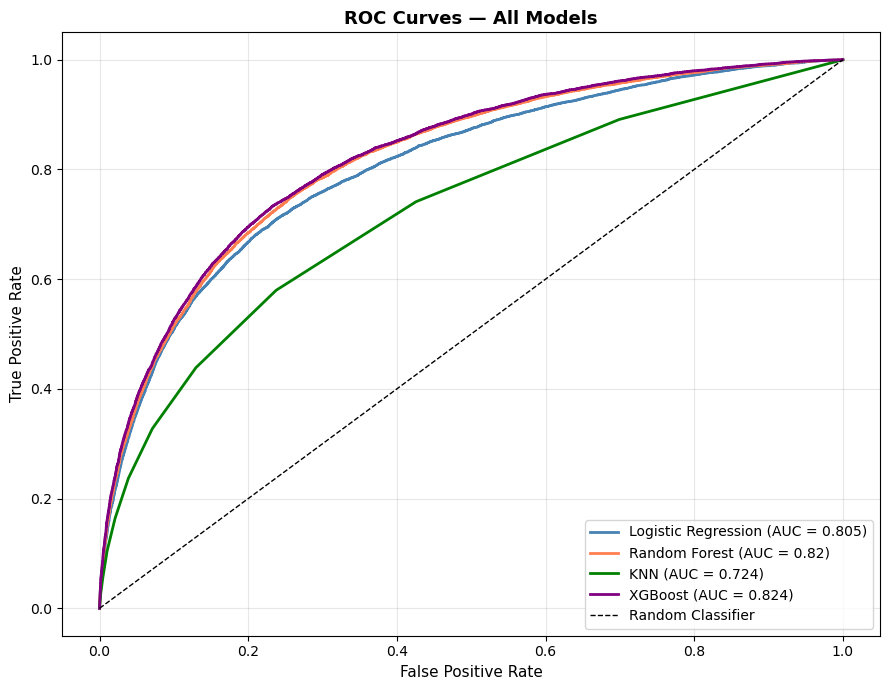

✅ Saved: 05_roc_curves.png


In [14]:
# ============================================================
# MILESTONE 3 — ROC Curve for all models
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

models_for_roc = [
    ("Logistic Regression", lr,  X_test_scaled),
    ("Random Forest",       rf,  X_test_final),
    ("KNN",                 knn, X_test_scaled),
    ("XGBoost",             xgb, X_test_final),
]

colors_roc = ["steelblue", "coral", "green", "purple"]

for (name, model, X_data), color in zip(models_for_roc, colors_roc):
    y_prob        = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _   = roc_curve(y_test, y_prob)
    auc           = round(roc_auc_score(y_test, y_prob), 3)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 05_roc_curves.png")

# Week 3 — Model Development: Methodology & Findings

## 1. Why Feature Selection First?

We started with 96 features after one-hot encoding. Training models on all 96 features 
would introduce noise, slow down training, and risk overfitting — where the model memorizes 
the training data instead of learning generalizable patterns. Feature selection identifies 
which variables genuinely contribute to predicting depression and which are irrelevant.

---

## 2. Why BorutaPy?

BorutaPy is a wrapper around Random Forest that uses a clever statistical approach — it 
creates random "shadow" copies of every feature, shuffles them, and checks whether each 
real feature performs better than its random shadow consistently across many iterations. 
Features that reliably beat their random counterparts are "confirmed." Features that never 
beat random noise are "rejected."

**Why we chose it:**
- It doesn't just rank features — it makes a definitive confirmed/rejected decision
- It accounts for feature interactions, not just individual correlations
- It is robust against the high dimensionality of our one-hot encoded dataset

**Result:** BorutaPy confirmed 41 out of 96 features and rejected 55 — including almost 
all State-level features, suggesting depression risk is driven by individual health and 
socioeconomic factors rather than geography.

---

## 3. Why RFE (Recursive Feature Elimination)?

RFE takes a different approach — it trains a Logistic Regression model, ranks all features 
by their coefficient weights, drops the weakest features, retrains, and repeats until it 
reaches the target number of features. It evaluates features from a linear model's 
perspective, complementing Boruta's tree-based perspective.

**Why we chose it:**
- Provides a second independent opinion on feature importance
- Uses Logistic Regression as its base — directly relevant since LR is one of our models
- Confirms or challenges Boruta's findings

**Result:** RFE selected 40 features. The overlap with Boruta was 25 features — these are 
the most robustly confirmed predictors. The main disagreement was on State features — RFE 
selected 14 states while Boruta rejected all but one (Hawaii). We trusted Boruta's 
conservative approach and used its 41 confirmed features as the final set.

---

## 4. Why These 4 Models?

We trained four models that represent fundamentally different approaches to classification:

**Logistic Regression** — The simplest model. It finds a linear boundary between depressed 
and non-depressed respondents. Useful as a baseline and highly interpretable — you can 
directly read the coefficient of each feature to understand its direction and magnitude 
of effect.

**Random Forest** — An ensemble of hundreds of decision trees, each trained on a random 
subset of features and data. It captures non-linear relationships and feature interactions 
that Logistic Regression misses. Robust and generally hard to overfit.

**KNN (K-Nearest Neighbors)** — Classifies each person based on the K most similar people 
in the training data. Simple and intuitive but computationally expensive and sensitive to 
irrelevant features. Included to demonstrate the full model comparison landscape.

**XGBoost** — Gradient boosting builds trees sequentially, where each new tree corrects 
the errors of the previous one. It is currently one of the most powerful and widely used 
algorithms for structured/tabular data in industry and competitions.

---

## 5. What Do the Evaluation Metrics Mean?

With 20.2% of respondents having depression, a naive model that predicts "No Depression" 
for everyone would achieve 79.8% accuracy — which sounds good but is clinically useless. 
This is why we use multiple metrics:

**Accuracy** — What percentage of all predictions were correct. Misleading for imbalanced 
datasets. A model predicting everyone as "No Depression" scores 79.8% accuracy.

**Precision** — Of everyone the model flagged as depressed, what percentage actually were? 
High precision = fewer false alarms. Important if resources for follow-up are limited.

**Recall** — Of everyone who actually has depression, what percentage did the model catch? 
High recall = fewer missed cases. Critical in healthcare — missing a depressed person is 
more costly than a false alarm.

**F1 Score** — The harmonic mean of Precision and Recall. Balances both — useful when you 
care about both false positives and false negatives equally.

**AUC (Area Under ROC Curve)** — Measures the model's ability to distinguish between 
depressed and non-depressed respondents across all possible decision thresholds. A score 
of 0.5 = random guessing, 1.0 = perfect. AUC is threshold-independent and robust to 
class imbalance — making it the primary metric for model selection here.

---

## 6. Model Results and Why XGBoost Won

| Model               | Accuracy | Precision | Recall | F1    | AUC   |
|---------------------|----------|-----------|--------|-------|-------|
| Logistic Regression | 77.20%   | 45.60%    | 67.05% | 54.29%| 80.52%|
| Random Forest       | 75.61%   | 43.72%    | 72.56% | 54.57%| 81.96%|
| KNN                 | 81.50%   | 60.72%    | 23.70% | 34.09%| 72.41%|
| XGBoost             | 76.20%   | 44.54%    | 72.94% | 55.31%| 82.42%|

**KNN warning:** KNN achieved the highest accuracy (81.50%) but the lowest Recall (23.70%) 
and lowest AUC (72.41%). This means it overwhelmingly predicts "No Depression" — it looks 
accurate only because 79.8% of the dataset is No Depression. It is the worst model for 
this problem despite appearing best on accuracy alone. This is the classic imbalanced 
dataset trap.

**XGBoost** achieved the best AUC (82.42%) and best Recall (72.94%) — meaning it correctly 
identified 73% of all actual depression cases while maintaining the strongest overall 
discriminative power. For a healthcare screening tool where missing cases is costly, 
XGBoost is the clear choice.

**Logistic Regression** performed surprisingly well (80.52% AUC) for such a simple model, 
suggesting the relationships in the data have a meaningful linear component. This also 
validates our feature selection — clean, well-chosen features allow even simple models 
to perform well.

---

## 7. Next Step — Hyperparameter Tuning

XGBoost was trained with reasonable default parameters. GridSearchCV will systematically 
test combinations of key hyperparameters (tree depth, learning rate, number of trees, 
subsampling rate) using 3-fold cross validation to find the optimal configuration — 
potentially improving AUC further before we extract final feature importance.

In [15]:
# ============================================================
# MILESTONE 4 — GridSearchCV on XGBoost
#
# We tune the most impactful hyperparameters only
# to keep runtime reasonable
# ============================================================

param_grid = {
    "n_estimators"  : [100, 200],
    "max_depth"     : [4, 6, 8],
    "learning_rate" : [0.05, 0.1],
    "subsample"     : [0.8, 1.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,                  # 3-fold cross validation
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV on XGBoost... this may take 15-30 mins ⏳")
grid_search.fit(X_train_final, y_train)

print(f"\n✅ GridSearchCV complete")
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<20} : {value}")
print(f"\nBest CV AUC score : {grid_search.best_score_ * 100:.2f}%")

Running GridSearchCV on XGBoost... this may take 15-30 mins ⏳
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ GridSearchCV complete

Best parameters:
  learning_rate        : 0.1
  max_depth            : 4
  n_estimators         : 200
  subsample            : 0.8

Best CV AUC score : 82.20%


In [16]:
# ============================================================
# MILESTONE 4 — Evaluate Tuned XGBoost vs Baseline
# ============================================================

# Train tuned model with best parameters
xgb_tuned = XGBClassifier(
    **grid_search.best_params_,
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
xgb_tuned.fit(X_train_final, y_train)

# Evaluate both
baseline_metrics = evaluate_model("XGBoost (Baseline)", xgb,       X_test_final, y_test)
tuned_metrics    = evaluate_model("XGBoost (Tuned)",    xgb_tuned, X_test_final, y_test)

print(f"{'='*75}")
print(f"{'XGBOOST — BASELINE vs TUNED':^75}")
print(f"{'='*75}")
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 75)
for m in [baseline_metrics, tuned_metrics]:
    print(f"{m['Model']:<25} {m['Accuracy']:>9.2f}% {m['Precision']:>9.2f}% "
          f"{m['Recall']:>9.2f}% {m['F1 Score']:>9.2f}% {m['AUC']:>9.2f}%")
print("=" * 75)

# Which one to use going forward
best_xgb     = xgb_tuned if tuned_metrics["AUC"] >= baseline_metrics["AUC"] else xgb
best_xgb_tag = "Tuned" if tuned_metrics["AUC"] >= baseline_metrics["AUC"] else "Baseline"
print(f"\n✅ Using XGBoost ({best_xgb_tag}) for feature importance and final results")

                        XGBOOST — BASELINE vs TUNED                        

Model                       Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
XGBoost (Baseline)            76.20%     44.54%     72.94%     55.31%     82.42%
XGBoost (Tuned)               76.00%     44.31%     73.41%     55.26%     82.56%

✅ Using XGBoost (Tuned) for feature importance and final results


Tuned model wins but only marginally , AUC improved from 82.42% to 82.56%, Recall improved slightly from 72.94% to 73.41%. 
It means our baseline XGBoost was already well configured and there wasn't much room to squeeze out improvement. 
GridSearchCV confirmed the model is robust.
The best parameters make intuitive sense too:

max_depth=4 — shallower trees prevent overfitting

n_estimators=200 — more trees = more stable predictions

learning_rate=0.1 — standard, not too aggressive

subsample=0.8 — using 80% of data per tree adds regularization

Feature Importance

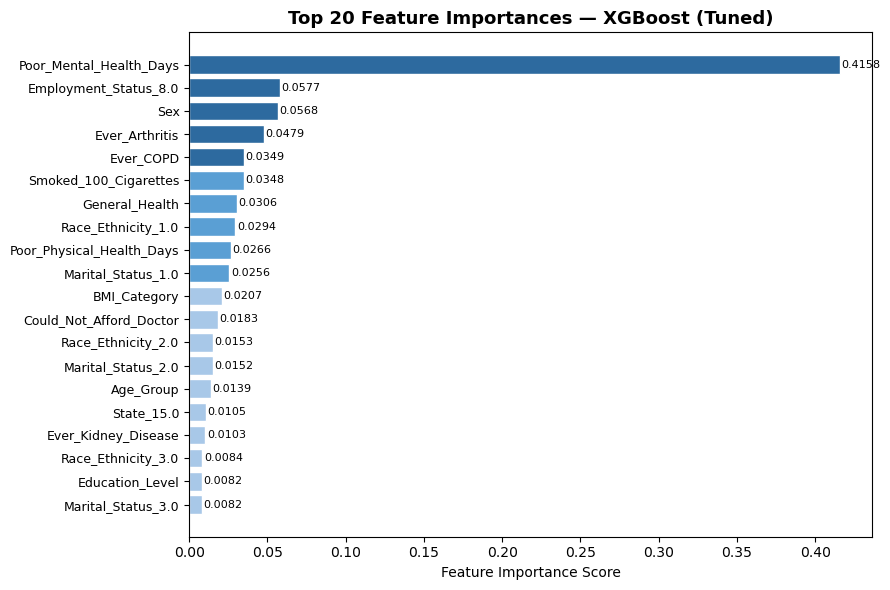

✅ Saved: 06_feature_importance.png

FULL FEATURE IMPORTANCE RANKING

Rank   Feature                               Importance
-------------------------------------------------------
1      Poor_Mental_Health_Days                   0.4158
2      Employment_Status_8.0                     0.0577
3      Sex                                       0.0568
4      Ever_Arthritis                            0.0479
5      Ever_COPD                                 0.0349
6      Smoked_100_Cigarettes                     0.0348
7      General_Health                            0.0306
8      Race_Ethnicity_1.0                        0.0294
9      Poor_Physical_Health_Days                 0.0266
10     Marital_Status_1.0                        0.0256
11     BMI_Category                              0.0207
12     Could_Not_Afford_Doctor                   0.0183
13     Race_Ethnicity_2.0                        0.0153
14     Marital_Status_2.0                        0.0152
15     Age_Group                   

In [18]:
# ============================================================
# MILESTONE 5 — Feature Importance
# ============================================================

# Get feature importances from tuned XGBoost
importance_df = pd.DataFrame({
    "Feature"    : FINAL_FEATURES,
    "Importance" : best_xgb.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Top 20 for visualization
top20 = importance_df.head(20)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

colors_imp = ["#2d6a9f" if i < 5 else "#5a9fd4" if i < 10 else "#a8c8e8" 
              for i in range(len(top20))]

ax.barh(top20["Feature"][::-1], top20["Importance"][::-1], 
        color=colors_imp[::-1], edgecolor="white")

ax.set_title("Top 20 Feature Importances — XGBoost (Tuned)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Importance Score", fontsize=10)
ax.tick_params(axis="y", labelsize=9)

for i, (val, name) in enumerate(zip(top20["Importance"][::-1], 
                                     top20["Feature"][::-1])):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 06_feature_importance.png")

# Print full ranking
print(f"\n{'='*50}")
print(f"FULL FEATURE IMPORTANCE RANKING")
print(f"{'='*50}")
print(f"\n{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("-" * 55)
for i, row in importance_df.iterrows():
    print(f"{i+1:<6} {row['Feature']:<35} {row['Importance']:>12.4f}")
    

## Feature Importance Interpretation — XGBoost (Tuned)

### Dominant Predictor: Poor Mental Health Days (0.4158)
Poor_Mental_Health_Days is by far the most important feature — nearly 7x more 
important than the second predictor. This is consistent with our EDA finding 
(correlation = 0.413) and makes clinical sense: the number of days a person 
reports poor mental health is essentially a direct self-assessment of their 
mental state. This variable alone carries more predictive power than all 
demographic, lifestyle, and chronic condition variables combined.

**Clinical implication:** Self-reported mental health days could serve as a 
simple, low-cost screening tool for depression risk.

### Employment Status — Unable to Work (0.0577)
Employment_Status_8.0 represents respondents who are unable to work due to 
health reasons. This group shows the second highest importance — people unable 
to work due to illness carry significantly elevated depression risk, reflecting 
the bidirectional relationship between physical disability and mental health.

### Sex (0.0568)
Females show nearly double the depression rate of males (25.9% vs 14.1%). 
Sex is the third most important predictor, consistent with well-established 
clinical literature on gender differences in depression prevalence.

### Chronic Conditions — Arthritis and COPD (0.0479, 0.0349)
Both Ever_Arthritis and Ever_COPD rank in the top 5. Chronic pain and 
respiratory conditions are strongly associated with depression — living with 
persistent physical illness significantly elevates mental health risk. This 
suggests depression screening should be standard practice for patients with 
chronic conditions.

### General Health and Physical Health Days (0.0306, 0.0266)
Overall self-rated health and days of poor physical health both contribute 
meaningfully — reinforcing the pattern that depression rarely exists in 
isolation from broader physical health deterioration.

### Notable Lower-Ranked Features
- **Income Level (rank 22)** — Despite showing strong patterns in EDA, 
  XGBoost captures income's effect indirectly through correlated features 
  like Employment Status and Could Not Afford Doctor
- **Exercise (rank 27)** — Protective but less predictive than health status 
  variables once other factors are controlled for
- **Diet — Fruit and Vegetables (ranks 38-40)** — Minimal predictive power 
  for depression in this dataset

### Summary
The model reveals that depression prediction is dominated by mental and 
physical health self-assessments, followed by demographic factors (sex, 
employment, marital status) and chronic conditions. Socioeconomic variables 
(income, education) play a secondary role when health status variables are 
present — suggesting that health deterioration mediates the relationship 
between poverty and depression rather than income directly causing it.

Model Results csv

In [19]:
# ============================================================
# DELIVERABLE — Save Model_Results.csv
# ============================================================

# Full metrics table for all 4 models
all_metrics = [
    evaluate_model("Logistic Regression",  lr,        X_test_scaled, y_test),
    evaluate_model("Random Forest",        rf,        X_test_final,  y_test),
    evaluate_model("KNN",                  knn,       X_test_scaled, y_test),
    evaluate_model("XGBoost (Baseline)",   xgb,       X_test_final,  y_test),
    evaluate_model("XGBoost (Tuned)",      xgb_tuned, X_test_final,  y_test),
]

metrics_df = pd.DataFrame(all_metrics)

# Add top 5 features column
top5 = importance_df.head(5)["Feature"].tolist()
metrics_df["Top_Features"] = ", ".join(top5)
metrics_df["Best_Params"]  = str(grid_search.best_params_)

# Save
RESULTS_CSV = TABLES_DIR / "Model_Results.csv"
metrics_df.to_csv(RESULTS_CSV, index=False)

print(f"✅ Saved: {RESULTS_CSV}")
print(f"\nModel_Results.csv contents:")
print(metrics_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].to_string(index=False))

✅ Saved: /Users/ishamandawkar/PulsePredictor/outputs/tables/Model_Results.csv

Model_Results.csv contents:
              Model  Accuracy  Precision  Recall  F1 Score   AUC
Logistic Regression     77.20      45.60   67.05     54.29 80.52
      Random Forest     75.61      43.72   72.56     54.57 81.96
                KNN     81.50      60.72   23.70     34.09 72.41
 XGBoost (Baseline)     76.20      44.54   72.94     55.31 82.42
    XGBoost (Tuned)     76.00      44.31   73.41     55.26 82.56


Final Summary

In [20]:
# ============================================================
# WEEK 3 COMPLETE — Final Summary
# ============================================================

print("=" * 60)
print("WEEK 3 SUMMARY — MODEL DEVELOPMENT & EVALUATION")
print("=" * 60)
print(f"""
Feature Selection:
  Started with        : 96 features
  Final selected      : 41 features (BorutaPy)
  Dropped             : 55 features

Model Performance (AUC):
  Logistic Regression : 80.52%
  Random Forest       : 81.96%
  KNN                 : 72.41%  ← worst (accuracy trap)
  XGBoost (Baseline)  : 82.42%
  XGBoost (Tuned)     : 82.56%  ← best model

Best Model: XGBoost (Tuned)
  Accuracy  : 76.00%
  Precision : 44.31%
  Recall    : 73.41%
  F1 Score  : 55.26%
  AUC       : 82.56%

Top 5 Predictors:
  1. Poor_Mental_Health_Days  (0.4158)
  2. Employment_Status_8.0    (0.0577)
  3. Sex                      (0.0568)
  4. Ever_Arthritis           (0.0479)
  5. Ever_COPD                (0.0349)

Deliverables saved:
  ✅ outputs/figures/05_roc_curves.png
  ✅ outputs/figures/06_feature_importance.png
  ✅ outputs/tables/Model_Results.csv
""")
print("=" * 60)

WEEK 3 SUMMARY — MODEL DEVELOPMENT & EVALUATION

Feature Selection:
  Started with        : 96 features
  Final selected      : 41 features (BorutaPy)
  Dropped             : 55 features

Model Performance (AUC):
  Logistic Regression : 80.52%
  Random Forest       : 81.96%
  KNN                 : 72.41%  ← worst (accuracy trap)
  XGBoost (Baseline)  : 82.42%
  XGBoost (Tuned)     : 82.56%  ← best model

Best Model: XGBoost (Tuned)
  Accuracy  : 76.00%
  Precision : 44.31%
  Recall    : 73.41%
  F1 Score  : 55.26%
  AUC       : 82.56%

Top 5 Predictors:
  1. Poor_Mental_Health_Days  (0.4158)
  2. Employment_Status_8.0    (0.0577)
  3. Sex                      (0.0568)
  4. Ever_Arthritis           (0.0479)
  5. Ever_COPD                (0.0349)

Deliverables saved:
  ✅ outputs/figures/05_roc_curves.png
  ✅ outputs/figures/06_feature_importance.png
  ✅ outputs/tables/Model_Results.csv



## Model Performance Results

Among the models evaluated, **XGBoost achieved the strongest overall performance**, with the highest AUC score.

Key results:

• AUC: **82.56%**  
• Recall: **73.41%**  
• Accuracy: **76.00%**

These results indicate that the model has a strong ability to distinguish between individuals who have experienced depression and those who have not.

In practical terms, the model correctly ranks depressed versus non-depressed individuals more than 80% of the time, demonstrating meaningful predictive power for population-level analysis.

#### Visualization & Storytelling

## From Models to Insights

After selecting the best-performing model (XGBoost), the next step is to interpret the model results and communicate insights effectively.

Feature importance analysis is used to identify the variables that contribute most strongly to depression prediction. These insights are then visualized through an interactive Tableau dashboard.

The dashboard highlights:

• key predictors of depression risk  
• demographic differences in depression rates  
• relationships between lifestyle, health, and mental health indicators

By combining machine learning modeling with visual analytics, the project transforms complex survey data into interpretable insights that can support public health understanding of depression risk factors.

In [22]:
# Load full clean dataset for Tableau exports
df = pd.read_csv(PROCESSED / "BRFSS2021_clean.csv")
print(f"✅ Loaded clean dataset: {df.shape}")

✅ Loaded clean dataset: (262716, 97)


In [23]:
# ============================================================
# WEEK 4 — Export data for Tableau
# ============================================================

TABLEAU_DIR = BASE_DIR / "outputs" / "tableau"
TABLEAU_DIR.mkdir(parents=True, exist_ok=True)

# ── Export 1: Feature Importance Table ──────────────────────
importance_df.to_csv(TABLEAU_DIR / "feature_importance.csv", index=False)
print("✅ Saved: feature_importance.csv")

# ── Export 2: Model Performance Scores ──────────────────────
metrics_df.to_csv(TABLEAU_DIR / "model_scores.csv", index=False)
print("✅ Saved: model_scores.csv")

# ── Export 3: Depression rates by key variables ──────────────
tableau_vars = [
    "General_Health", "Income_Level", "BMI_Category",
    "Age_Group", "Sex", "Exercise_Past30Days",
    "Smoked_100_Cigarettes", "Ever_Arthritis", "Ever_COPD"
]

depression_rates = []
for col in tableau_vars:
    rates = df.groupby(col)["Ever_Depressive_Disorder"].agg(
        Depression_Rate=lambda x: round(x.mean() * 100, 2),
        Count="count"
    ).reset_index()
    rates.rename(columns={col: "Value"}, inplace=True)
    rates["Variable"] = col
    rates["Value"]    = rates["Value"].astype(str)
    depression_rates.append(rates)

depression_rates_df = pd.concat(depression_rates, ignore_index=True)
depression_rates_df = depression_rates_df[["Variable", "Value", "Depression_Rate", "Count"]]
depression_rates_df.to_csv(TABLEAU_DIR / "depression_rates_by_variable.csv", index=False)
print("✅ Saved: depression_rates_by_variable.csv")

# ── Export 4: Correlation matrix (for heatmap) ──────────────
numeric_cols_corr = [
    "Ever_Depressive_Disorder", "Age_Group", "Sex",
    "Education_Level", "Income_Level", "Exercise_Past30Days",
    "Smoked_100_Cigarettes", "BMI_Category", "General_Health",
    "Poor_Physical_Health_Days", "Poor_Mental_Health_Days",
    "Could_Not_Afford_Doctor", "Ever_Arthritis", "Ever_COPD"
]

corr_long = df[numeric_cols_corr].corr().round(3).reset_index()
corr_long = corr_long.melt(id_vars="index", var_name="Variable_2", value_name="Correlation")
corr_long.rename(columns={"index": "Variable_1"}, inplace=True)
corr_long.to_csv(TABLEAU_DIR / "correlation_matrix.csv", index=False)
print("✅ Saved: correlation_matrix.csv")

print(f"\n✅ All Tableau exports saved to: {TABLEAU_DIR}")
print(f"\nFiles ready for Tableau:")
print(f"  → feature_importance.csv       (bar chart: top risk factors)")
print(f"  → model_scores.csv             (KPI cards: accuracy, recall, AUC)")
print(f"  → depression_rates_by_variable.csv (interactive filters)")
print(f"  → correlation_matrix.csv       (heatmap)")

✅ Saved: feature_importance.csv
✅ Saved: model_scores.csv
✅ Saved: depression_rates_by_variable.csv
✅ Saved: correlation_matrix.csv

✅ All Tableau exports saved to: /Users/ishamandawkar/PulsePredictor/outputs/tableau

Files ready for Tableau:
  → feature_importance.csv       (bar chart: top risk factors)
  → model_scores.csv             (KPI cards: accuracy, recall, AUC)
  → depression_rates_by_variable.csv (interactive filters)
  → correlation_matrix.csv       (heatmap)
